In [204]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  
import matplotlib.colors as mcolors
from fields import ScalarField, VectorField

Pravimo neophodna polja (brzina i pritisak):

In [205]:
x_p = np.linspace(0, 1, 25)
y_p = np.linspace(0, 1, 25)
X_p, Y_p = np.meshgrid(x_p, y_p)
P_pocetni = np.zeros((25, 25)) 
# Centrirana Gausova raspodela (kupola pritiska)
# Pritisak je najjači (1.0) tačno u centru (0.5, 0.5) i glatko opada ka ivicama
P_pocetni = np.exp(-((X_p - 0.5)**2 + (Y_p - 0.5)**2) / 0.04)
pritisak = ScalarField('Pritisak', P_pocetni, X_p, Y_p)

x_v = np.linspace(0, 1, 26)
y_v = np.linspace(0, 1, 26)
X_v, Y_v = np.meshgrid(x_v, y_v)
U_pocetno = np.zeros((26, 26))
V_pocetno = np.zeros((26, 26))

brzina = VectorField('Brzina', X_v, Y_v, U_pocetno, V_pocetno)
grad = pritisak.Gradient()

np.savez('pritisak.npz', 
         ime=pritisak.ime, 
         data=pritisak.vrednosti_grid,
         gradient_podaci = grad,
         x_grid=pritisak.x_grid,
         y_grid=pritisak.y_grid)


lap = brzina.Laplacian()
div = brzina.Divergence()
np.savez('brzina.npz', 
         ime = brzina.ime,
         x_grid = brzina.x_grid,
         y_grid = brzina.y_grid,
         u = brzina.u,
         v = brzina.v,
         laplacian = lap,
         divergence = div)

IMPLENETIRANJE FORMULE


In [206]:
def SimulationStep(brzina, pritisak, rho = 1.0, nu = 0.1, dt = 0.02):  
    grad_pritiska_y, grad_pritiska_x = pritisak.Gradient()
    brzina_nu = brzina.MnozenjeSkalarom(nu) 
    lap_u_x, lap_u_y = brzina_nu.Laplacian()
    adv_x, adv_y = brzina.Advekcija()
    dU_dt_x = -((1/rho) * grad_pritiska_x) + lap_u_x - adv_x

    dV_dt_y = -((1/rho) * grad_pritiska_y) + lap_u_y - adv_y

    U_novo = brzina.u + dU_dt_x * dt

    V_novo = brzina.v + dV_dt_y * dt

    print("--- PROVERA DIMENZIJA ---")
    print("Pritisak oblik:", pritisak.vrednosti_grid.shape)
    print("Brzina U oblik:", brzina.u.shape)
    
    grad_pritiska_y, grad_pritiska_x = pritisak.Gradient()
    print("Gradijent Prit. X oblik:", grad_pritiska_x.shape)
    
    brzina_nu = brzina.MnozenjeSkalarom(nu) 
    lap_u_x, lap_u_y = brzina_nu.Laplacian()
    print("Laplasijan U X oblik:", lap_u_x.shape)
    
    adv_x, adv_y = brzina.Advekcija()
    print("Advekcija X oblik:", adv_x.shape)
    print("-------------------------")

    return VectorField('Nova Brzina', brzina.x_grid, brzina.y_grid, U_novo, V_novo)


In [207]:
nova_brzina = SimulationStep(brzina, pritisak)
np.savez('nova_brzina.npz', 
         ime = nova_brzina.ime,
         x_grid = nova_brzina.x_grid,
         y_grid = nova_brzina.y_grid,
         u = nova_brzina.u,
         v = nova_brzina.v,
         laplacian = nova_brzina.Laplacian(),
         divergence = nova_brzina.Divergence())

--- PROVERA DIMENZIJA ---
Pritisak oblik: (25, 25)
Brzina U oblik: (26, 26)
Gradijent Prit. X oblik: (26, 26)
Laplasijan U X oblik: (26, 26)
Advekcija X oblik: (26, 26)
-------------------------


In [208]:
istorija_u = []
istorija_v = []
brzina.u[10][10] = 0
for i in range(100):
    brzina = SimulationStep(brzina, pritisak)
    brzina.u[:, 0] = 0
    brzina.u[0, :] = 0
    brzina.u[:, -1] = 0
    brzina.u[-1, 0] = 0
    istorija_u.append(brzina.u.copy())
    istorija_v.append(brzina.v.copy())
    print(brzina.u[12][12])

--- PROVERA DIMENZIJA ---
Pritisak oblik: (25, 25)
Brzina U oblik: (26, 26)
Gradijent Prit. X oblik: (26, 26)
Laplasijan U X oblik: (26, 26)
Advekcija X oblik: (26, 26)
-------------------------
-0.019954714624313113
--- PROVERA DIMENZIJA ---
Pritisak oblik: (25, 25)
Brzina U oblik: (26, 26)
Gradijent Prit. X oblik: (26, 26)
Laplasijan U X oblik: (26, 26)
Advekcija X oblik: (26, 26)
-------------------------
-0.032059079956524655
--- PROVERA DIMENZIJA ---
Pritisak oblik: (25, 25)
Brzina U oblik: (26, 26)
Gradijent Prit. X oblik: (26, 26)
Laplasijan U X oblik: (26, 26)
Advekcija X oblik: (26, 26)
-------------------------
-0.04029296168843856
--- PROVERA DIMENZIJA ---
Pritisak oblik: (25, 25)
Brzina U oblik: (26, 26)
Gradijent Prit. X oblik: (26, 26)
Laplasijan U X oblik: (26, 26)
Advekcija X oblik: (26, 26)
-------------------------
-0.0461938917776199
--- PROVERA DIMENZIJA ---
Pritisak oblik: (25, 25)
Brzina U oblik: (26, 26)
Gradijent Prit. X oblik: (26, 26)
Laplasijan U X oblik: (26

/tmp/ipykernel_101117/1466353709.py:6: RuntimeWarning: invalid value encountered in subtract
  dU_dt_x = -((1/rho) * grad_pritiska_x) + lap_u_x - adv_x
/tmp/ipykernel_101117/1466353709.py:8: RuntimeWarning: invalid value encountered in subtract
  dV_dt_y = -((1/rho) * grad_pritiska_y) + lap_u_y - adv_y


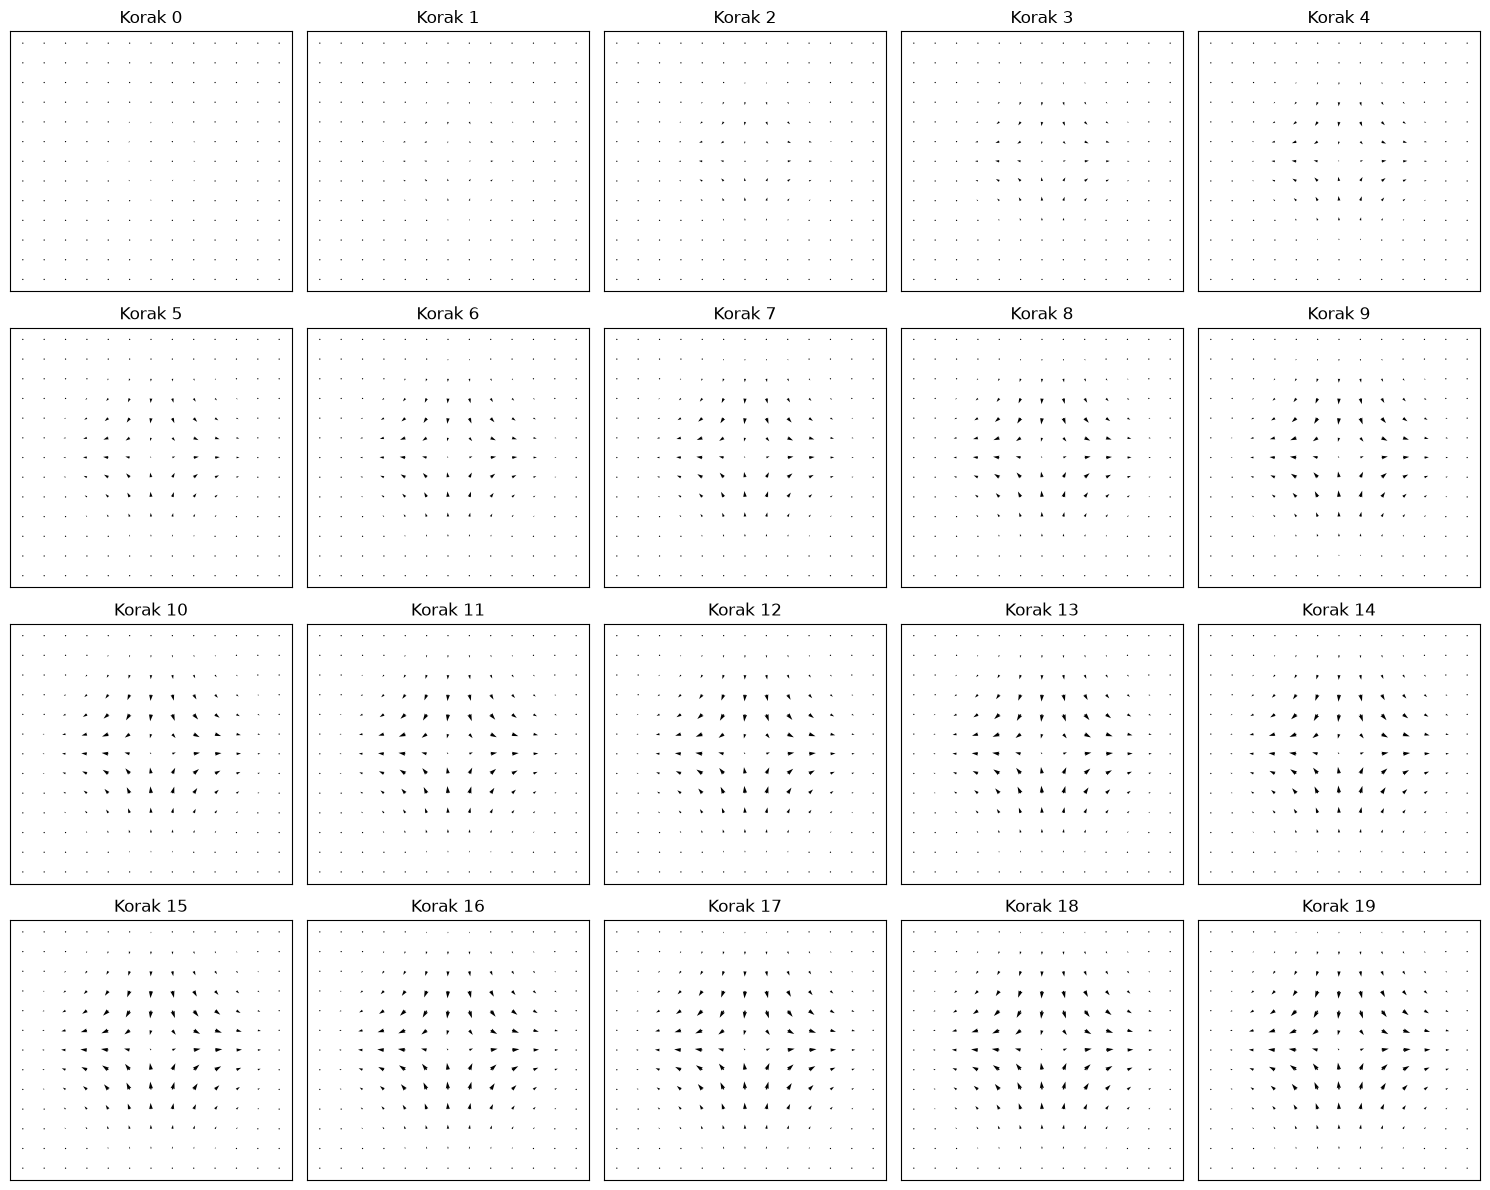

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. MORAMO definisati tačne koordinate ćoškova (26x26) na kojima žive U i V
x_vektorski = np.linspace(0, 1, 26)
y_vektorski = np.linspace(0, 1, 26)
X_novo, Y_novo = np.meshgrid(x_vektorski, y_vektorski)

fig, ose = plt.subplots(4, 5, figsize=(15, 12))
ose_lista = ose.flatten()

for i in range(20):
    ax = ose_lista[i]
    U = istorija_u[i]
    V = istorija_v[i]

    ax.quiver(
        X_novo[::2, ::2],
        Y_novo[::2, ::2],
        U[::2, ::2],
        V[::2, ::2],
        scale=15,  
        width=0.005,
        headwidth=3,
    )

    ax.set_title(f"Korak {i}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

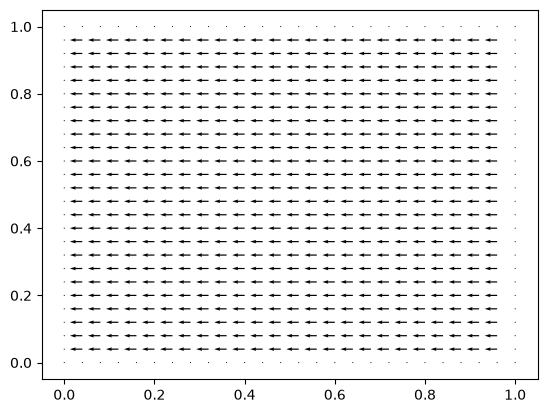

In [214]:
x = np.linspace(0, 1, 25)
y = np.linspace(0, 1, 25)
X, Y = np.meshgrid(x, y)
X_vektorski = np.linspace(0, 1, 26)
Y_vektorski = np.linspace(0, 1, 26)
X_novo, Y_novo = np.meshgrid(X_vektorski, Y_vektorski)

P_pocetni = 1.0 - X

pritisak_u_centrima = ScalarField('pritisak u centrima', P_pocetni, X, Y)
gradient_u_centrima_v, gradient_u_centrima_u = pritisak_u_centrima.Gradient()
plt.quiver(X_novo, Y_novo, gradient_u_centrima_u, gradient_u_centrima_v)